In [30]:
from langsmith._internal._background_thread import TracingQueueItem
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

import os

load_dotenv(override=True)


api_key = os.getenv("OPENAI_API_KEY")

In [31]:
from langfuse import get_client

langfuse = get_client()

# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

Langfuse client is authenticated and ready!


In [32]:
from typing import TypedDict

class State(TypedDict):

    graph_state: str

In [33]:
def node_1(state):
    print("Note 1")

    
    return {"graph_state": state["graph_state"] + "I AM"}

def node_2(state):
    print("Note 2")

    
    return {"graph_state": state["graph_state"] + " Happy"}

def node_3(state):
    print("Note 3")

    
    return {"graph_state": state["graph_state"] + " Sad"}

In [34]:
from typing import Literal
import random

def mood(state) -> Literal["node_2", "node_3"]:

    graph_state = state["graph_state"]

    if random.random() < 0.05:

        return "node_2"
    else:
        return "node_3"

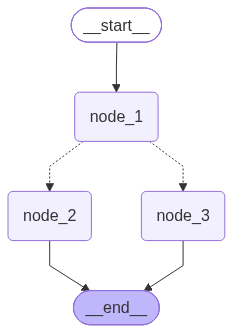

In [35]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Graph
builder = StateGraph(state_schema=State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)


builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1",mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)


graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
print(graph.invoke({"graph_state": ""}))

Note 1
Note 3
{'graph_state': 'I AM Sad'}


In [37]:
from langchain_core.messages import HumanMessage

def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b


llm = ChatOpenAI(model="gpt-5-mini")

llm_with_tool = llm.bind_tools([multiply])

llm_with_tool.invoke([HumanMessage(content="can u help me calculate 2 * 6")])

AIMessage(content='2 × 6 = 12.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 149, 'total_tokens': 230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EKf95huaxhGB8S7297usxINBhnTPT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a07079-e27c-7da0-be3a-fa685efe75e8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 149, 'output_tokens': 81, 'total_tokens': 230, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [38]:
from langgraph.graph import add_messages
from typing import Annotated

class MessageState(TypedDict):

    messages: Annotated[list[str], add_messages]

In [39]:
from langchain_core.messages import AIMessage
initial_message = [HumanMessage(content="Hey my name is abhin"), AIMessage(content="Hey abhin how are you")]

new_message = [HumanMessage(content="I am good, thank you! How are you")]

add_messages(initial_message, new_message)

[HumanMessage(content='Hey my name is abhin', additional_kwargs={}, response_metadata={}, id='b2519ba8-e312-451c-9045-fbfb65467b7c'),
 AIMessage(content='Hey abhin how are you', additional_kwargs={}, response_metadata={}, id='6bfd0c30-5029-4691-8795-770b80a224fa', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am good, thank you! How are you', additional_kwargs={}, response_metadata={}, id='d1437ab2-411e-4f16-89d2-4239b8d90443')]

In [40]:

class MessageState(TypedDict):
    messages: Annotated[list[str], add_messages]



def chat_node_with_tool(state) -> AIMessage:

    return {"messages": llm_with_tool.invoke(state["messages"])}

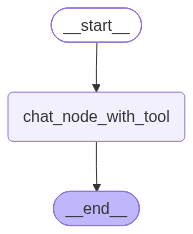

In [41]:
builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool", chat_node_with_tool)


builder.add_edge(START, "chat_node_with_tool")
builder.add_edge("chat_node_with_tool", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
graph.invoke({"messages":[HumanMessage(content="can u multiply 15 and 80")]})

{'messages': [HumanMessage(content='can u multiply 15 and 80', additional_kwargs={}, response_metadata={}, id='1d42e2f3-dbcf-4771-8945-cbdf8bd379b8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 147, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EKf982QLJ9srHkKXGUZAW0gQJWon1', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a07079-eb7f-7b63-be91-0b6b6dc189ae-0', tool_calls=[{'name': 'multiply', 'args': {'a': 15, 'b': 80}, 'id': 'call_Z28QLtlQW5ikR2lHk2UdbO0H', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 147, 'output_tokens': 26, 't

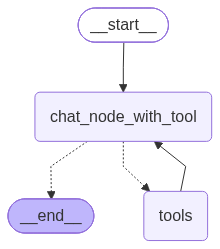

In [43]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict


system_message = SystemMessage(content="You are a helpfull assistant, be nice to the user")

class MessageState(TypedDict):
    messages: Annotated[list[str], add_messages]



def chat_node_with_tool(state) -> AIMessage:

    return {"messages": [llm_with_tool.invoke([system_message] + state["messages"])]}

def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b


llm = ChatOpenAI(model="gpt-5-mini", streaming=True)

llm_with_tool = llm.bind_tools([multiply])

builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool",chat_node_with_tool)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "chat_node_with_tool")
builder.add_conditional_edges("chat_node_with_tool", tools_condition)
builder.add_edge("tools", "chat_node_with_tool")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
from langfuse.langchain import CallbackHandler
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [48]:
result = graph.stream({"messages": [HumanMessage(content="hey I am not feeling well today")]},config={"callbacks": [langfuse_handler]}, stream_mode="messages")

In [ ]:
for s in graph.stream({"messages": [HumanMessage(content="multiply 100 and 56")]}):
    print(s)

{'chat_node_with_tool': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 234, 'prompt_tokens': 161, 'total_tokens': 395, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EKesUfTIYKRG58Q0qWESOTrYNHfkZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0706a-2e75-70a2-bf25-9b2743fa49f1-0', tool_calls=[{'name': 'multiply', 'args': {'a': 100, 'b': 56}, 'id': 'call_dgfp9s4DqimdPfx6ph7Lw2nA', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 161, 'output_tokens': 234, 'total_tokens': 395, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 

In [50]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv

# 1. Reload credentials from .env
load_dotenv(override=True)

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Langfuse v4 imports
from langfuse import get_client
from langfuse.langchain import CallbackHandler

# 2. Verify connection
langfuse = get_client()
print("Langfuse Authenticated:", langfuse.auth_check())

# 3. Define tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b

# 4. Initialize LLM with streaming=True (REQUIRED for TTFT)
llm = ChatOpenAI(model="gpt-5-mini", streaming=True)
llm_with_tool = llm.bind_tools([multiply])
system_message = SystemMessage(content="You are a helpful assistant, be nice to the user")

# 5. Define Graph State & Node
class MessageState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node_with_tool(state) -> AIMessage:
    return {"messages": [llm_with_tool.invoke([system_message] + state["messages"])]}

builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool", chat_node_with_tool)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "chat_node_with_tool")
builder.add_conditional_edges("chat_node_with_tool", tools_condition)
builder.add_edge("tools", "chat_node_with_tool")

graph = builder.compile()

# 6. Stream tokens with Langfuse handler to capture TTFT
langfuse_handler = CallbackHandler()

print("\n--- Streaming Output ---")
for chunk, metadata in graph.stream(
    {"messages": [HumanMessage(content="I am feeling very overhelmed today")]},
    config={"callbacks": [langfuse_handler]},
    stream_mode="messages"
):
    if chunk.content:
        print(chunk.content, end="", flush=True)
print("\n------------------------\n")

# 7. Flush events to Langfuse so TTFT is immediately visible in the UI
langfuse.flush()
print("Traces flushed to Langfuse! Check your trace generation for TTFT.")


Langfuse Authenticated: True

--- Streaming Output ---
I’m sorry you’re feeling that way — that sounds really heavy. You’re not alone in this. Would you like to try a quick, grounding step now? I can stay with you through it or help with something practical.

Here are a few short things that often help right away. Pick one that feels doable:

1. Breathe for 1 minute: inhale 4 seconds — hold 4 — exhale 6 (or just breathe slowly). Repeat until your heart slows a bit.  
2. 5-4-3-2-1 grounding: name 5 things you can see, 4 you can touch, 3 you can hear, 2 you can smell, 1 you can taste. It pulls attention into the present.  
3. Small physical change: stand up, stretch, walk to a window, splash water on your face, or get a drink of water. Movement often reduces tension.  
4. Break it down: write everything on your mind (no order). Then pick the top 1–3 things that actually need attention in the next few hours. Ignore the rest for now.  
5. Use a tiny timer: set 15–25 minutes (Pomodoro) and 

In [51]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv

load_dotenv(override=True)

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langfuse import get_client
from langfuse.langchain import CallbackHandler

# 1. Initialize client & verify
langfuse = get_client()
print("Langfuse Authenticated:", langfuse.auth_check())

# 2. Define tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

# 3. Model & Tools (streaming=True ensures TTFT is captured)
llm = ChatOpenAI(model="gpt-5-mini", streaming=True)
llm_with_tool = llm.bind_tools([multiply])
system_message = SystemMessage(content="You are a helpful assistant with memory. Be friendly and concise.")

# 4. State & Node
class MessageState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node_with_tool(state) -> AIMessage:
    return {"messages": [llm_with_tool.invoke([system_message] + state["messages"])]}

# 5. Build Graph with MemorySaver Checkpointer
builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool", chat_node_with_tool)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "chat_node_with_tool")
builder.add_conditional_edges("chat_node_with_tool", tools_condition)
builder.add_edge("tools", "chat_node_with_tool")

# Attach in-memory checkpointer
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# 6. Define conversation session / thread
thread_id = "session-conversation-001"

def ask_agent(user_query: str, thread_id: str):
    print(f"\nUser: {user_query}")
    print("Agent: ", end="", flush=True)

    # Langfuse callback handler for tracing & TTFT
    handler = CallbackHandler()

    # Pass thread_id to both LangGraph (configurable) and Langfuse (metadata/tags)
    config = {
        "configurable": {"thread_id": thread_id},
        "callbacks": [handler],
        "metadata": {
            "session_id": thread_id,
            "conversation_id": thread_id
        },
        "tags": [thread_id, "multi-turn"]
    }

    for chunk, metadata in graph.stream(
        {"messages": [HumanMessage(content=user_query)]},
        config=config,
        stream_mode="messages"
    ):
        if chunk.content:
            print(chunk.content, end="", flush=True)
    print()

# --- Multi-Turn Execution ---

# Turn 1: Introduce information
ask_agent("Hi, my favorite number is 42 and my name is Abhin.", thread_id)

# Turn 2: Test memory + tool calculation
ask_agent("Can you multiply my favorite number by 3?", thread_id)

# Turn 3: Test memory recall
ask_agent("Do you still remember what my name is?", thread_id)

# 7. Flush all traces to Langfuse
langfuse.flush()
print("\nAll traces flushed to Langfuse!")


Langfuse Authenticated: True

User: Hi, my favorite number is 42 and my name is Abhin.
Agent: Nice to meet you, Abhin — thanks for telling me. I’ll remember that your name is Abhin and your favorite number is 42. I can use your name in future replies and reference 42 when it’s helpful (examples, jokes, personalization). 

Would you like me to remember any other preferences or a nickname? If you want these changed or removed later, just say so.

User: Can you multiply my favorite number by 3?
Agent: 126126

User: Do you still remember what my name is?
Agent: Yes — your name is Abhin. Would you like me to use a nickname or update it?

All traces flushed to Langfuse!


In [52]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv

load_dotenv(override=True)

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langfuse import get_client
from langfuse.langchain import CallbackHandler

# 1. Verify Langfuse
langfuse = get_client()

# 2. Tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

# 3. Model with tools
llm = ChatOpenAI(model="gpt-5-mini", streaming=True)
llm_with_tool = llm.bind_tools([multiply])
system_message = SystemMessage(content="You are a helpful assistant with memory. Be friendly and concise.")

# 4. State & Node
class MessageState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node_with_tool(state) -> AIMessage:
    return {"messages": [llm_with_tool.invoke([system_message] + state["messages"])]}

# 5. Build Graph with Checkpointer
builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool", chat_node_with_tool)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "chat_node_with_tool")
builder.add_conditional_edges("chat_node_with_tool", tools_condition)
builder.add_edge("tools", "chat_node_with_tool")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# 6. Multi-turn conversation helper with Langfuse Session linking
thread_id = "chat-session-001"

def ask_agent(user_query: str, thread_id: str):
    print(f"\nUser: {user_query}")
    print("Agent: ", end="", flush=True)

    handler = CallbackHandler()

    config = {
        "configurable": {"thread_id": thread_id},
        "callbacks": [handler],
        "metadata": {
            "langfuse_session_id": thread_id,  # <-- Key for Langfuse Sessions tab!
            "langfuse_user_id": "abhin"
        }
    }

    for chunk, metadata in graph.stream(
        {"messages": [HumanMessage(content=user_query)]},
        config=config,
        stream_mode="messages"
    ):
        if chunk.content:
            print(chunk.content, end="", flush=True)
    print()

# --- Run Turns ---
ask_agent("Hi, my favorite number is 42 and my name is Abhin.", thread_id)
ask_agent("Can you multiply my favorite number by 3?", thread_id)
ask_agent("Do you still remember what my name is?", thread_id)

# 7. Flush so it immediately displays in Langfuse
langfuse.flush()
print("\nDone! Check the Sessions tab now in Langfuse.")



User: Hi, my favorite number is 42 and my name is Abhin.
Agent: Nice to meet you, Abhin — got it: your favorite number is 42. I’ll remember that. How can I help you today?

User: Can you multiply my favorite number by 3?
Agent: 126126

User: Do you still remember what my name is?
Agent: Yes — your name is Abhin. Would you like me to do anything else?

Done! Check the Sessions tab now in Langfuse.


In [54]:
from langchain_core.messages import AIMessageChunk
import os
import ast
import operator as op
from typing import Annotated, TypedDict
from dotenv import load_dotenv

load_dotenv(override=True)

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langfuse import get_client
from langfuse.langchain import CallbackHandler

# 1. Initialize Langfuse
langfuse = get_client()

# 2. General-purpose Calculator Tool
_OPERATORS = {
    ast.Add: op.add,
    ast.Sub: op.sub,
    ast.Mult: op.mul,
    ast.Div: op.truediv,
    ast.Pow: op.pow,
    ast.USub: op.neg,
    ast.UAdd: op.pos,
    ast.Mod: op.mod,
}

def _eval_ast(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        return _OPERATORS[type(node.op)](_eval_ast(node.left), _eval_ast(node.right))
    elif isinstance(node, ast.UnaryOp):
        return _OPERATORS[type(node.op)](_eval_ast(node.operand))
    raise TypeError(f"Unsupported math operation: {type(node).__name__}")

def calculator(expression: str) -> str:
    """Calculate the result of a mathematical expression.
    
    Supports +, -, *, /, %, **, parentheses, etc.
    Examples:
        - "42 * 3 + 15"
        - "(120 / 4) ** 2"
        - "250 * 0.18"
    Args:
        expression: The mathematical expression string to calculate.
    """
    try:
        cleaned = expression.replace("^", "**")
        tree = ast.parse(cleaned, mode="eval")
        return str(_eval_ast(tree.body))
    except Exception as e:
        return f"Error calculating: {e}"

# 3. Model & Bind Calculator Tool
llm = ChatOpenAI(model="gpt-5-mini", streaming=True)
llm_with_tool = llm.bind_tools([calculator])
system_message = SystemMessage(
    content="You are a helpful assistant with memory and a calculator tool. "
            "Use the calculator tool for mathematical calculations."
)

# 4. State & Node
class MessageState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node_with_tool(state) -> AIMessage:
    return {"messages": [llm_with_tool.invoke([system_message] + state["messages"])]}

# 5. Build Graph with Checkpointer
builder = StateGraph(MessageState)
builder.add_node("chat_node_with_tool", chat_node_with_tool)
builder.add_node("tools", ToolNode([calculator]))

builder.add_edge(START, "chat_node_with_tool")
builder.add_conditional_edges("chat_node_with_tool", tools_condition)
builder.add_edge("tools", "chat_node_with_tool")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# 6. Conversation Session Helper
thread_id = "calc-session-001"

def ask_agent(user_query: str, thread_id: str):
    print(f"\nUser: {user_query}")
    print("Agent: ", end="", flush=True)

    handler = CallbackHandler()
    config = {
        "configurable": {"thread_id": thread_id},
        "callbacks": [handler],
        "metadata": {
            "langfuse_session_id": thread_id,
            "langfuse_user_id": "abhin"
        }
    }

    for chunk, metadata in graph.stream(
        {"messages": [HumanMessage(content=user_query)]},
        config=config,
        stream_mode="messages"
    ):
        # Only print the AI assistant's verbal tokens, not internal tool outputs
        if isinstance(chunk, AIMessageChunk) and chunk.content:
            print(chunk.content, end="", flush=True)
    print()
# --- Run Multi-Turn Calculations ---
ask_agent("Hey, remember that I bought 4 items priced at $37.50 each.", thread_id)
ask_agent("Can you calculate my total with 8.5% sales tax added?", thread_id)
ask_agent("Now divide that total evenly among 3 people.", thread_id)

# 7. Flush traces to Langfuse
langfuse.flush()
print("\nDone! Check Langfuse Sessions tab for calc-session-001.")



User: Hey, remember that I bought 4 items priced at $37.50 each.
Agent: Yes — I remember. 4 × $37.50 = $150.00 total.

Would you like me to:
- Add sales tax (tell me the rate or location), or
- Split the cost between people, or
- Save this purchase to your memory/budget?
If something else, tell me what you want done.

User: Can you calculate my total with 8.5% sales tax added?
Agent: Sure — sales tax = 150 × 8.5% = $12.75.  
Total = $150.00 + $12.75 = $162.75.

Want me to split this among people or save it to your memory/budget?

User: Now divide that total evenly among 3 people.
Agent: Dividing the total of $162.75 evenly among 3 people gives $54.25 each.

Done! Check Langfuse Sessions tab for calc-session-001.
